# Forecasting Sales

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


# Load clean data from CSV files

In [3]:
orders = pd.read_csv('olist_clean/orders_clean.csv')
payments = pd.read_csv('olist_clean/order_payments_clean.csv')
customers = pd.read_csv('olist_clean/customers_clean.csv')
products = pd.read_csv('olist_clean/products_clean.csv')
sellers = pd.read_csv('olist_clean/sellers_clean.csv')
order_items = pd.read_csv('olist_clean/order_items_clean.csv')
reviews = pd.read_csv('olist_clean/order_reviews_clean.csv')
geolocation = pd.read_csv('olist_clean/geolocation_clean.csv')

print("✅ All CSV files loaded successfully!")
print(f"Orders: {len(orders):,} rows")
print(f"Payments: {len(payments):,} rows")
print(f"Customers: {len(customers):,} rows")
print(f"Products: {len(products):,} rows")
print(f"Sellers: {len(sellers):,} rows")
print(f"Order Items: {len(order_items):,} rows")
print(f"Reviews: {len(reviews):,} rows")

✅ All CSV files loaded successfully!
Orders: 99,441 rows
Payments: 103,886 rows
Customers: 99,441 rows
Products: 32,951 rows
Sellers: 3,095 rows
Order Items: 112,650 rows
Reviews: 99,224 rows


# Prepare data for forecasting

In [4]:
# Convert date column to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Merge orders with payments
df_sales = orders.merge(payments, on='order_id')

# Filter only delivered orders
df_sales = df_sales[df_sales['order_status'] == 'delivered']

# Create monthly sales aggregation
df_sales['year_month'] = df_sales['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df_sales.groupby('year_month').agg({
    'payment_value': 'sum'
}).reset_index()

# Convert period to string for plotting
monthly_sales['year_month_str'] = monthly_sales['year_month'].astype(str)
monthly_sales['month_num'] = range(1, len(monthly_sales) + 1)

print(" Monthly sales data prepared!")
print(f"Total months: {len(monthly_sales)}")
print(monthly_sales.head(10))

 Monthly sales data prepared!
Total months: 22
  year_month  payment_value year_month_str  month_num
0    2016-10       46566.71        2016-10          1
1    2016-12          19.62        2016-12          2
2    2017-01      127545.67        2017-01          3
3    2017-02      271298.65        2017-02          4
4    2017-03      414369.39        2017-03          5
5    2017-04      390952.18        2017-04          6
6    2017-05      567066.73        2017-05          7
7    2017-06      490225.60        2017-06          8
8    2017-07      566403.93        2017-07          9
9    2017-08      646000.61        2017-08         10


# Visualize historical sales

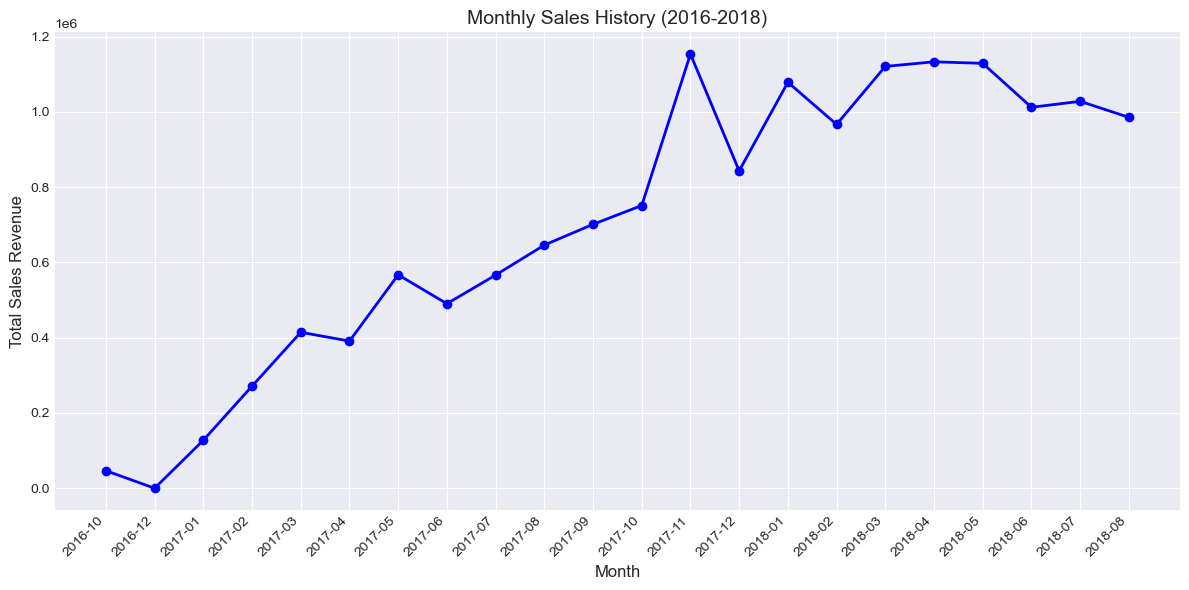

Highest month: 2017-11 with $1,153,528.05
Lowest month: 2016-12 with $19.62


In [7]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['year_month_str'], monthly_sales['payment_value'], 'b-o', linewidth=2, markersize=6)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales Revenue', fontsize=12)
plt.title('Monthly Sales History (2016-2018)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Highest month: {monthly_sales.loc[monthly_sales['payment_value'].idxmax(), 'year_month_str']} with ${monthly_sales['payment_value'].max():,.2f}")
print(f"Lowest month: {monthly_sales.loc[monthly_sales['payment_value'].idxmin(), 'year_month_str']} with ${monthly_sales['payment_value'].min():,.2f}")

# Build forecasting model

In [6]:
# Prepare data for model
X = monthly_sales[['month_num']].values
y = monthly_sales['payment_value'].values

# Split data into training (80%) and testing (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ Model trained successfully!")
print(f"Slope (trend): ${model.coef_[0]:,.2f} per month")
print(f"Intercept: ${model.intercept_:,.2f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

✅ Model trained successfully!
Slope (trend): $69,572.01 per month
Intercept: $-29,955.00
Mean Absolute Error (MAE): $304,049.27
Root Mean Squared Error (RMSE): $341,948.27


# Forecast next 6 months

In [7]:
# Predict next 6 months
last_month_num = monthly_sales['month_num'].max()
future_months = np.array(range(last_month_num + 1, last_month_num + 7)).reshape(-1, 1)
future_predictions = model.predict(future_months)

# Create a dataframe for future predictions
last_date = pd.to_datetime(monthly_sales['year_month_str'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=6, freq='MS')
future_df = pd.DataFrame({
    'month': future_dates,
    'month_num': future_months.flatten(),
    'predicted_sales': future_predictions
})
future_df['month_str'] = future_df['month'].dt.strftime('%Y-%m')

print("✅ Forecast for next 6 months:")
print(future_df[['month_str', 'predicted_sales']])

✅ Forecast for next 6 months:
  month_str  predicted_sales
0   2018-09     1.570201e+06
1   2018-10     1.639773e+06
2   2018-11     1.709345e+06
3   2018-12     1.778917e+06
4   2019-01     1.848489e+06
5   2019-02     1.918061e+06


# Plot actual vs forecast

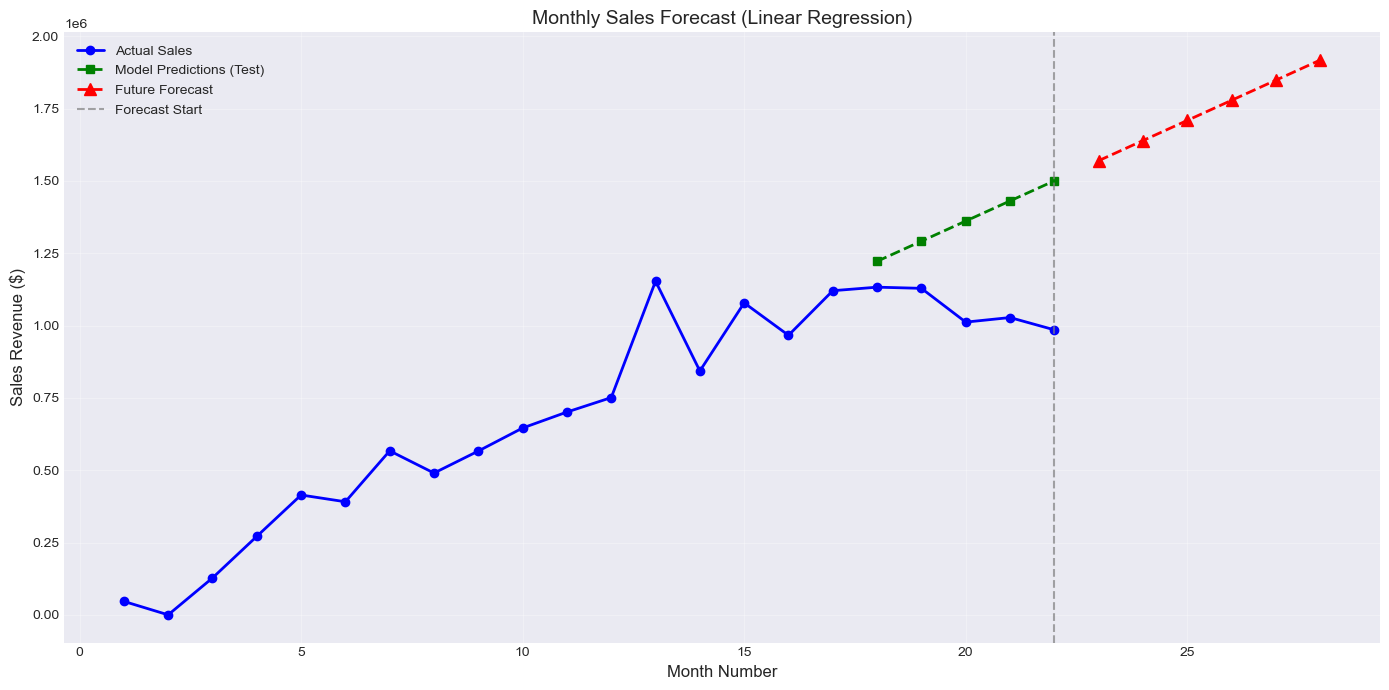

In [8]:
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(monthly_sales['month_num'], monthly_sales['payment_value'], 
         'b-o', linewidth=2, markersize=6, label='Actual Sales')

# Plot predictions on test data
plt.plot(X_test, y_pred, 'g--s', linewidth=2, markersize=6, label='Model Predictions (Test)')

# Plot future predictions
plt.plot(future_months, future_predictions, 'r--^', linewidth=2, markersize=8, label='Future Forecast')

# Add vertical line to separate past from future
plt.axvline(x=last_month_num, color='gray', linestyle='--', alpha=0.7, label='Forecast Start')

plt.xlabel('Month Number', fontsize=12)
plt.ylabel('Sales Revenue ($)', fontsize=12)
plt.title('Monthly Sales Forecast (Linear Regression)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Forecast by product category

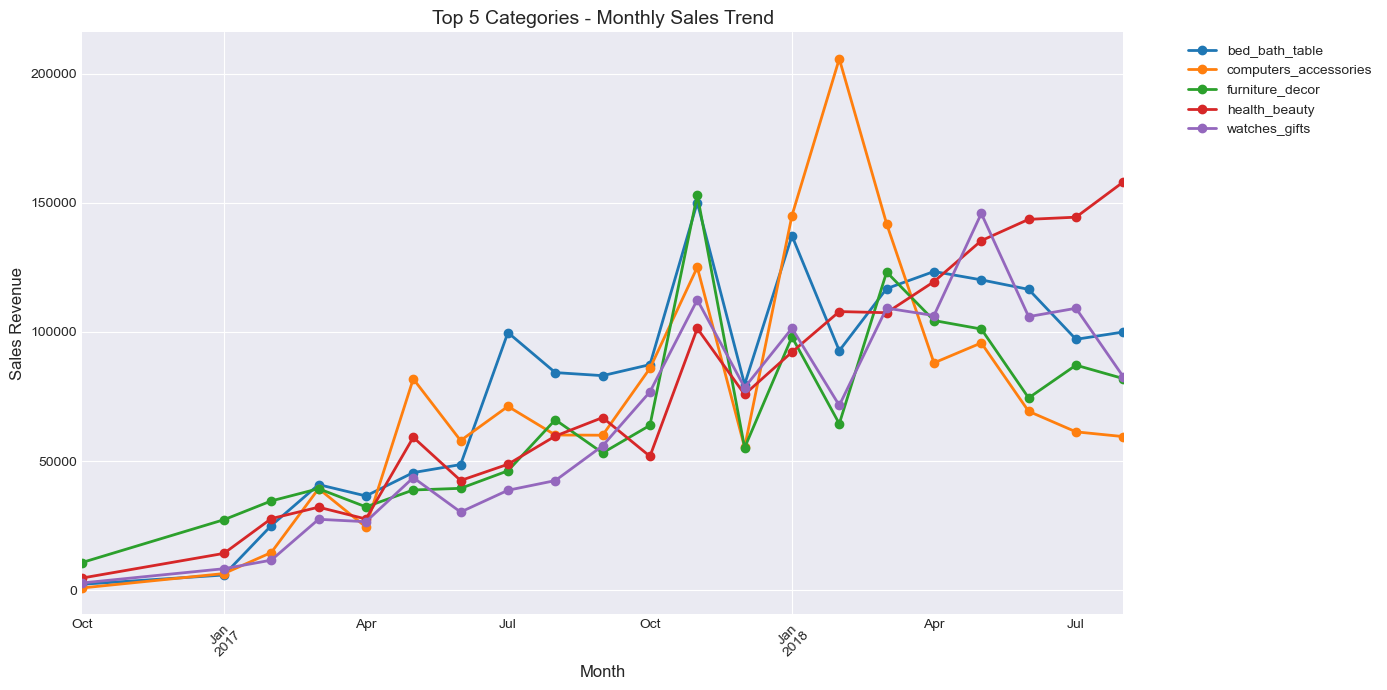

In [9]:
# Merge to get category information
df_with_cat = df_sales.merge(order_items, on='order_id')
df_with_cat = df_with_cat.merge(products, on='product_id')

# Get top 5 categories by revenue
top_categories = df_with_cat.groupby('product_category_name_english')['payment_value'].sum().nlargest(5).index

# Create monthly sales by category
monthly_category = df_with_cat[df_with_cat['product_category_name_english'].isin(top_categories)]
monthly_category['year_month'] = monthly_category['order_purchase_timestamp'].dt.to_period('M')
category_monthly = monthly_category.groupby(['year_month', 'product_category_name_english'])['payment_value'].sum().reset_index()

# Pivot for plotting
pivot_category = category_monthly.pivot(index='year_month', columns='product_category_name_english', values='payment_value')

# Plot
pivot_category.plot(figsize=(14, 7), linewidth=2, marker='o')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales Revenue', fontsize=12)
plt.title('Top 5 Categories - Monthly Sales Trend', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save forecast results

In [10]:
# Save monthly sales data
monthly_sales.to_csv('monthly_sales_data.csv', index=False)

# Save forecast results
future_df.to_csv('sales_forecast_next_6_months.csv', index=False)

print(" Forecast results saved!")
print("  - monthly_sales_data.csv")
print("  - sales_forecast_next_6_months.csv")

 Forecast results saved!
  - monthly_sales_data.csv
  - sales_forecast_next_6_months.csv
